In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
torch.manual_seed(2)

## Automatic Gradients

In [3]:
x = torch.tensor(2.0, requires_grad=True)

y = x**2 + 3*x
y.backward()

print(y)
print(x.grad)   # derivative = 2x + 3 → 7

tensor(10., grad_fn=<AddBackward0>)
tensor(7.)


In [4]:
x = torch.tensor([
    [1.0, 2.0],
    [2.0, 3.0],
    [3.0, 4.0],
    [4.0, 5.0],
    [5.0, 6.0],
    [6.0, 7.0],
    [7.0, 8.0],
    [8.0, 9.0],
    [9.0, 10.0],
    [10.0, 11.0]
])

y = torch.tensor([
    [3.0],
    [5.0],
    [7.0],
    [9.0],
    [11.0],
    [13.0],
    [15.0],
    [17.0],
    [19.0],
    [21.0]
])

In [5]:
import torch.nn as nn

loss_fn = nn.MSELoss()

In [6]:
import torch.optim as optim

In [7]:
losses_sgd = []
losses_adam = []

In [8]:
model_sgd = nn.Linear(2, 1)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.1)

for epoch in range(1000):
    y_pred = model_sgd(x)
    loss = loss_fn(y_pred, y)

    optimizer_sgd.zero_grad()
    loss.backward()
    optimizer_sgd.step()

    losses_sgd.append(loss.item())

In [9]:
model_adam = nn.Linear(2, 1)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.02)

for epoch in range(1000):
    y_pred = model_adam(x)
    loss = loss_fn(y_pred, y)

    optimizer_adam.zero_grad()
    loss.backward()
    optimizer_adam.step()

    losses_adam.append(loss.item())

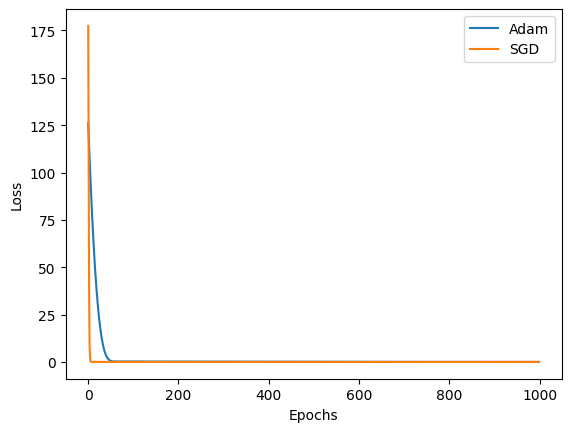

In [10]:
import matplotlib.pyplot as plt

plt.plot(losses_adam, label="Adam")
plt.plot(losses_sgd, label="SGD")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [11]:
x_test = torch.tensor([
    [1.0, 1.0],
    [2.0, 5.0],
    [3.0, 7.0],
    [6.0, 4.0],
    [10.0, 2.0]
])

y_test = torch.tensor([
    [2.0],
    [7.0],
    [10.0],
    [10.0],
    [12.0]
])

In [12]:
with torch.no_grad():
    y_pred = model_sgd(x_test)
    loss = loss_fn(y_pred, y_test)
    print("Test Loss using sgd:", loss.item())

Test Loss using sgd: 0.6343775987625122


In [13]:
with torch.no_grad():
    y_pred = model_adam(x_test)
    loss = loss_fn(y_pred, y_test)
    print("Test Loss using adam:", loss.item())

Test Loss using adam: 0.20519514381885529


## Conclusion
In simple problems, model performance is sensitive to initialization. Increasing data or training time reduces this effect. SGD converges faster for simple tasks, while Adam provides more stable but sometimes less optimal results.